# T03 Missing-Value Analysis

This notebook investigates missing-data patterns in `weatherAUS.csv` without imputing, dropping, or otherwise changing any observation. It does not perform preprocessing, outlier treatment, feature engineering, modelling, or T04 relationship EDA.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import display

from fdm_rainfall.data import load_weather_data
from fdm_rainfall.missing_values import (
    IMPORTANT_LOCATION_FEATURES,
    MAJOR_STRUCTURAL_FEATURES,
    comissingness_summary,
    location_missingness,
    location_year_missingness,
    missing_summary,
    proposal_missingness_comparison,
    rainfall_raintoday_relationship,
    row_missingness,
    structural_missingness_summary,
    target_missingness,
    temporal_missingness,
)

DATASET_PATH = PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv'
TABLES_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'missing_values'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 30)
print(f'Project root: {PROJECT_ROOT}')

Project root: D:\11.Running Projects\FDM Mini Project\FDM_Mini_Project


In [2]:
weather = load_weather_data(DATASET_PATH)
print(f'Loaded read-only for analysis: {weather.shape[0]:,} rows x {weather.shape[1]} columns')

Loaded read-only for analysis: 145,460 rows x 23 columns


## 1–2. Overall missingness and descriptive severity

Severity ranges used here are descriptive only: **No missingness = 0%**, **Low = >0% to <5%**, **Moderate = 5% to <20%**, and **High = ≥20%**. They do not automatically determine whether a feature should be kept, dropped, or imputed.

In [3]:
missing_summary_table = missing_summary(weather)
display(missing_summary_table)

,Feature,Missing count,Missing percentage,Non-missing count,Descriptive severity
0,Sunshine,69835,48.0098,75625,High missingness
1,Evaporation,62790,43.1665,82670,High missingness
2,Cloud3pm,59358,40.8071,86102,High missingness
3,Cloud9am,55888,38.4216,89572,High missingness
4,Pressure9am,15065,10.3568,130395,Moderate missingness
5,Pressure3pm,15028,10.3314,130432,Moderate missingness
6,WindDir9am,10566,7.2639,134894,Moderate missingness
7,WindGustDir,10326,7.0989,135134,Moderate missingness
8,WindGustSpeed,10263,7.0555,135197,Moderate missingness
9,Humidity3pm,4507,3.0984,140953,Low missingness


## 3. Row-level missingness

For this descriptive review, a row is labelled **very high missingness** when at least 10 of the 23 fields are missing. No row is removed.

In [4]:
row_result = row_missingness(weather, very_high_threshold=10)
row_missing_overview_table = row_result.overview
row_missing_distribution_table = row_result.distribution
display(row_missing_overview_table)
display(row_missing_distribution_table)

,Row-missingness metric,Value
0,Total rows,145460.0000
1,Rows with at least one missing value,89040.0000
2,Rows with at least one missing value (%),61.2127
3,Maximum missing fields in one row,21.0000
4,Very-high threshold (missing fields),10.0000
5,Rows meeting very-high threshold,3117.0000
6,Rows meeting very-high threshold (%),2.1429


,Missing fields per row,Row count,Row percentage
0,0,56420,38.7873
1,1,10909,7.4997
2,2,18346,12.6124
3,3,9782,6.7249
4,4,28675,19.7133
5,5,4141,2.8468
6,6,10229,7.0322
7,7,2277,1.5654
8,8,1072,0.7370
9,9,492,0.3382


## 4. Missingness by Location

Station coverage categories are mutually exclusive: **Complete absence = 100% missing**, **Good coverage = 0–5% missing**, and **Partial missingness = >5% but <100% missing**. The full 441-row location-feature table is saved; compact summaries are displayed here.

In [5]:
location_missing_table = location_missingness(weather)
temporal_missing_table = temporal_missingness(weather)
location_year_missing_table = location_year_missingness(weather)
structural_missingness_table = structural_missingness_summary(
    weather, location_missing_table, temporal_missing_table, location_year_missing_table
)
complete_absence_locations_table = (
    location_missing_table.query("`Coverage classification` == 'Complete absence'")
    .sort_values(['Feature', 'Location'])
    .reset_index(drop=True)
)
display(structural_missingness_table)
print('Locations where an important feature is entirely absent:')
display(complete_absence_locations_table[['Feature', 'Location', 'Record count']])

,Feature,Overall missing percentage,Complete-absence locations,Partial-missingness locations,Good-coverage locations,Fully complete locations,Minimum station missing percentage,Maximum station missing percentage,Station percentage spread,Minimum yearly missing percentage,Maximum yearly missing percentage,Yearly percentage spread,Locations with >=10pp within-station yearly spread,Median within-station yearly spread,Maximum within-station yearly spread,Provisional pattern,Mechanism caveat
0,Sunshine,48.0098,19,18,12,0,0.0313,100.0000,99.9687,0.0,74.1273,74.1273,19,0.8955,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
1,Evaporation,43.1665,16,19,14,0,0.0313,100.0000,99.9687,0.0,66.7169,66.7169,22,3.4294,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
2,Cloud9am,38.4216,12,24,13,2,0.0000,100.0000,100.0000,0.0,46.7703,46.7703,27,15.3589,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
3,Cloud3pm,40.8071,12,27,10,1,0.0000,100.0000,100.0000,0.0,54.6793,54.6793,30,30.8556,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
4,Pressure9am,10.3568,4,5,40,4,0.0000,100.0000,100.0000,0.0,13.3967,13.3967,7,1.3699,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
5,Pressure3pm,10.3314,4,5,40,5,0.0000,100.0000,100.0000,0.0,13.3743,13.3743,7,1.0959,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
6,WindDir9am,7.2639,0,18,31,0,0.2659,46.7588,46.4929,0.0,9.0037,9.0037,14,6.0165,67.9452,Likely temporal,Annual aggregates may reflect station mix; obs...
7,WindGustDir,7.0989,2,4,43,0,0.1566,100.0000,99.8434,0.0,19.9559,19.9559,9,4.7761,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
8,WindGustSpeed,7.0555,2,4,43,0,0.1566,100.0000,99.8434,0.0,19.9119,19.9119,9,4.7761,100.0000,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...


Locations where an important feature is entirely absent:


,Feature,Location,Record count
0,Cloud3pm,Adelaide,3193
1,Cloud3pm,BadgerysCreek,3009
2,Cloud3pm,Dartmoor,3009
3,Cloud3pm,GoldCoast,3040
4,Cloud3pm,MountGinini,3040
...,...,...,...
66,Sunshine,Wollongong,3040
67,WindGustDir,Albany,3040
68,WindGustDir,Newcastle,3039
69,WindGustSpeed,Albany,3040


## 5. Missingness over time

Missingness is summarized by year and by calendar month. Variation is interpreted descriptively; it does not establish a cause.

In [6]:
yearly_major = (
    temporal_missing_table.query("`Period type` == 'Year' and Feature in @MAJOR_STRUCTURAL_FEATURES")
    .pivot(index='Period', columns='Feature', values='Missing percentage')
)
monthly_major = (
    temporal_missing_table.query("`Period type` == 'Month of year' and Feature in @MAJOR_STRUCTURAL_FEATURES")
    .pivot(index='Period', columns='Feature', values='Missing percentage')
)
print('Yearly missing percentages for major affected features:')
display(yearly_major)
print('Calendar-month missing percentages for major affected features:')
display(monthly_major)
print('Evidence-based provisional pattern classifications:')
display(structural_missingness_table[['Feature', 'Complete-absence locations', 'Station percentage spread', 'Yearly percentage spread', 'Locations with >=10pp within-station yearly spread', 'Provisional pattern', 'Mechanism caveat']])

Yearly missing percentages for major affected features:


Feature,Cloud3pm,Cloud9am,Evaporation,Sunshine
Period,,,,
2007,0.0000,0.0000,0.0000,0.0000
2008,17.1366,16.6960,14.9339,14.2291
2009,34.5583,33.1586,34.0342,36.6073
2010,33.8637,32.9639,35.3057,37.0635
2011,39.4496,37.9048,37.6258,39.2873
2012,39.8404,38.0881,39.3017,42.4362
2013,41.5352,41.2367,39.1593,46.1164
2014,40.3746,39.9720,45.9994,51.1993
2015,42.0911,39.7260,48.5938,52.7873


Calendar-month missing percentages for major affected features:


Feature,Cloud3pm,Cloud9am,Evaporation,Sunshine
Period,,,,
1,43.0644,39.9290,43.6235,47.3557
2,42.0828,38.8029,43.1947,47.1695
3,41.0299,38.8219,43.0656,47.0324
4,40.6840,38.8485,43.6450,48.5281
5,41.3091,38.8227,44.6117,50.4606
6,39.9007,37.2044,44.9306,49.8344
7,37.0977,36.0249,41.1642,46.8191
8,38.8510,37.1300,42.3761,47.5806
9,39.6564,37.9467,42.0962,47.4570


Evidence-based provisional pattern classifications:


,Feature,Complete-absence locations,Station percentage spread,Yearly percentage spread,Locations with >=10pp within-station yearly spread,Provisional pattern,Mechanism caveat
0,Sunshine,19,99.9687,74.1273,19,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
1,Evaporation,16,99.9687,66.7169,22,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
2,Cloud9am,12,100.0000,46.7703,27,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
3,Cloud3pm,12,100.0000,54.6793,30,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
4,Pressure9am,4,100.0000,13.3967,7,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
5,Pressure3pm,4,100.0000,13.3743,7,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
6,WindDir9am,0,46.4929,9.0037,14,Likely temporal,Annual aggregates may reflect station mix; obs...
7,WindGustDir,2,99.8434,19.9559,9,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...
8,WindGustSpeed,2,99.8434,19.9119,9,Likely both station and time dependent,Annual aggregates may reflect station mix; obs...


## 6. Co-missingness

The Jaccard percentage is the intersection of two missingness masks divided by their union. It describes overlap without implying causation.

In [7]:
comissingness_table = comissingness_summary(weather)
display(comissingness_table.sort_values('Jaccard co-missingness percentage', ascending=False))

,Group,Feature A,Feature B,A missing,B missing,Both missing,A only missing,B only missing,Missing union,Both missing percentage of rows,Jaccard co-missingness percentage,Identical missingness masks
0,Rainfall / RainToday,Rainfall,RainToday,3261,3261,3261,0,0,3261,2.2419,100.0000,True
4,Wind,WindGustDir,WindGustSpeed,10326,10263,10263,63,0,10326,7.0555,99.3899,False
1,Pressure,Pressure9am,Pressure3pm,15065,15028,14804,261,224,15289,10.1774,96.8278,False
2,Cloud,Cloud9am,Cloud3pm,55888,59358,51744,4144,7614,63502,35.5727,81.4840,False
3,Sunshine / Evaporation,Sunshine,Evaporation,69835,62790,58547,11288,4243,74078,40.2496,79.0343,False
17,Wind,WindDir3pm,WindSpeed3pm,4228,3062,3062,1166,0,4228,2.1050,72.4219,False
18,Wind,WindSpeed9am,WindSpeed3pm,1767,3062,1213,554,1849,3616,0.8339,33.5454,False
6,Wind,WindGustDir,WindDir3pm,10326,4228,3258,7068,970,11296,2.2398,28.8421,False
10,Wind,WindGustSpeed,WindDir3pm,10263,4228,3212,7051,1016,11279,2.2082,28.4777,False
8,Wind,WindGustDir,WindSpeed3pm,10326,3062,2781,7545,281,10607,1.9119,26.2185,False


## 7. Target missingness

Target missingness is examined by date, location, year, and proximity to each station's observed time-series endpoints. Rows with missing `RainTomorrow` will later be excluded from supervised learning, but no exclusion is performed in T03.

In [8]:
target_result = target_missingness(weather)
target_missing_summary_table = target_result.overview
target_missing_by_location_table = target_result.by_location
target_missing_by_year_table = target_result.by_year
display(target_missing_summary_table)
print('Locations with the highest missing-target percentages:')
display(target_missing_by_location_table.sort_values('Missing target percentage', ascending=False).head(10))
display(target_missing_by_year_table)

,Target-missingness metric,Value
0,Total rows,145460
1,Missing RainTomorrow count,3267
2,Missing RainTomorrow percentage,2.246
3,Labelled RainTomorrow count,142193
4,Earliest missing-target date,2008-07-05
5,Latest missing-target date,2017-06-25
6,Missing targets exact station endpoints (count),10
7,Missing targets exact station endpoints (%),0.3061
8,All rows exact station endpoints (%),0.0674
9,Endpoint concentration ratio (0 days),4.5433


Locations with the highest missing-target percentages:


,Location,Record count,Missing target count,Missing target percentage,First missing-target date,Last missing-target date,Missing at station start,Missing at station end
18,Melbourne,3193,758,23.7394,2011-02-04,2016-04-29,0,0
45,Williamtown,3009,456,15.1545,2009-06-02,2016-12-29,0,0
29,PearceRAAF,3009,247,8.2087,2009-03-20,2017-06-20,0,0
43,Walpole,3006,187,6.2209,2009-02-03,2017-06-11,0,0
21,Moree,3009,155,5.1512,2011-09-08,2016-03-21,0,0
23,MountGinini,3040,133,4.3750,2009-06-05,2016-09-30,0,0
41,Uluru,1578,57,3.6122,2013-03-30,2017-06-25,0,1
0,Adelaide,3193,103,3.2258,2008-07-05,2017-06-25,0,1
24,Newcastle,3039,84,2.7641,2010-10-22,2017-04-08,0,0
4,BadgerysCreek,3009,81,2.6919,2009-06-11,2017-01-04,0,0


,Year,Record count,Missing target count,Missing target percentage
0,2007,61,0,0.0000
1,2008,2270,24,1.0573
2,2009,16789,194,1.1555
3,2010,16782,363,2.1630
4,2011,15407,281,1.8238
5,2012,15409,365,2.3687
6,2013,16415,318,1.9373
7,2014,17885,485,2.7118
8,2015,17885,654,3.6567
9,2016,17934,426,2.3754


## 8. Rainfall / RainToday missingness relationship

In [9]:
rain_relationship_table = rainfall_raintoday_relationship(weather)
display(rain_relationship_table)

,Relationship metric,Value
0,Rainfall missing count,3261
1,RainToday missing count,3261
2,Both missing count,3261
3,Rainfall-only missing count,0
4,RainToday-only missing count,0
5,Missingness fully coincides,True


## 9. Structural versus non-structural missingness

The station and yearly evidence supports only **provisional descriptive patterns**. The dataset alone cannot establish whether any mechanism is MCAR, MAR, or MNAR; those terms require assumptions or external evidence beyond the observed masks.

In [10]:
def complete_station_count(feature):
    return int(structural_missingness_table.set_index('Feature').loc[feature, 'Complete-absence locations'])

interpretation_framework_table = pd.DataFrame([
    {
        'Finding': 'Sunshine station pattern',
        'Observation': f"Sunshine is completely absent at {complete_station_count('Sunshine')} locations.",
        'Interpretation': 'This is consistent with strong station-dependent structural missingness.',
        'Future preprocessing consideration': 'Compare retention with grouped strategies, missing indicators, or native missing handling; do not default to a global mean.'
    },
    {
        'Finding': 'Evaporation station pattern',
        'Observation': f"Evaporation is completely absent at {complete_station_count('Evaporation')} locations.",
        'Interpretation': 'This is consistent with station-dependent measurement availability.',
        'Future preprocessing consideration': 'Compare station-aware strategies and model-native missing handling after splitting.'
    },
    {
        'Finding': 'Cloud station pattern',
        'Observation': f"Cloud9am is absent at {complete_station_count('Cloud9am')} locations and Cloud3pm at {complete_station_count('Cloud3pm')} locations.",
        'Interpretation': 'Station coverage is a major component; yearly variation also needs consideration.',
        'Future preprocessing consideration': 'Avoid assuming one global missingness mechanism; evaluate station-aware handling later.'
    },
    {
        'Finding': 'Rainfall and RainToday',
        'Observation': 'Their missingness masks are tested directly and reported with exception counts.',
        'Interpretation': 'Coincident masks would be consistent with RainToday depending on Rainfall availability.',
        'Future preprocessing consideration': 'Handle the paired fields consistently during T07 without deriving or filling them here.'
    },
    {
        'Finding': 'Missing target labels',
        'Observation': f"RainTomorrow is missing in {int(weather['RainTomorrow'].isna().sum()):,} rows.",
        'Interpretation': 'These rows cannot provide labels for supervised training.',
        'Future preprocessing consideration': 'Exclude them from supervised-learning datasets later, after the split strategy is defined.'
    },
])
display(interpretation_framework_table)

,Finding,Observation,Interpretation,Future preprocessing consideration
0,Sunshine station pattern,Sunshine is completely absent at 19 locations.,This is consistent with strong station-depende...,"Compare retention with grouped strategies, mis..."
1,Evaporation station pattern,Evaporation is completely absent at 16 locations.,This is consistent with station-dependent meas...,Compare station-aware strategies and model-nat...
2,Cloud station pattern,Cloud9am is absent at 12 locations and Cloud3p...,Station coverage is a major component; yearly ...,Avoid assuming one global missingness mechanis...
3,Rainfall and RainToday,Their missingness masks are tested directly an...,Coincident masks would be consistent with Rain...,Handle the paired fields consistently during T...
4,Missing target labels,"RainTomorrow is missing in 3,267 rows.",These rows cannot provide labels for supervise...,Exclude them from supervised-learning datasets...


## 10. Focused missingness visualizations

Four figures are used because each answers a distinct question: feature severity, row-pattern structure, station dependence, and yearly variation.

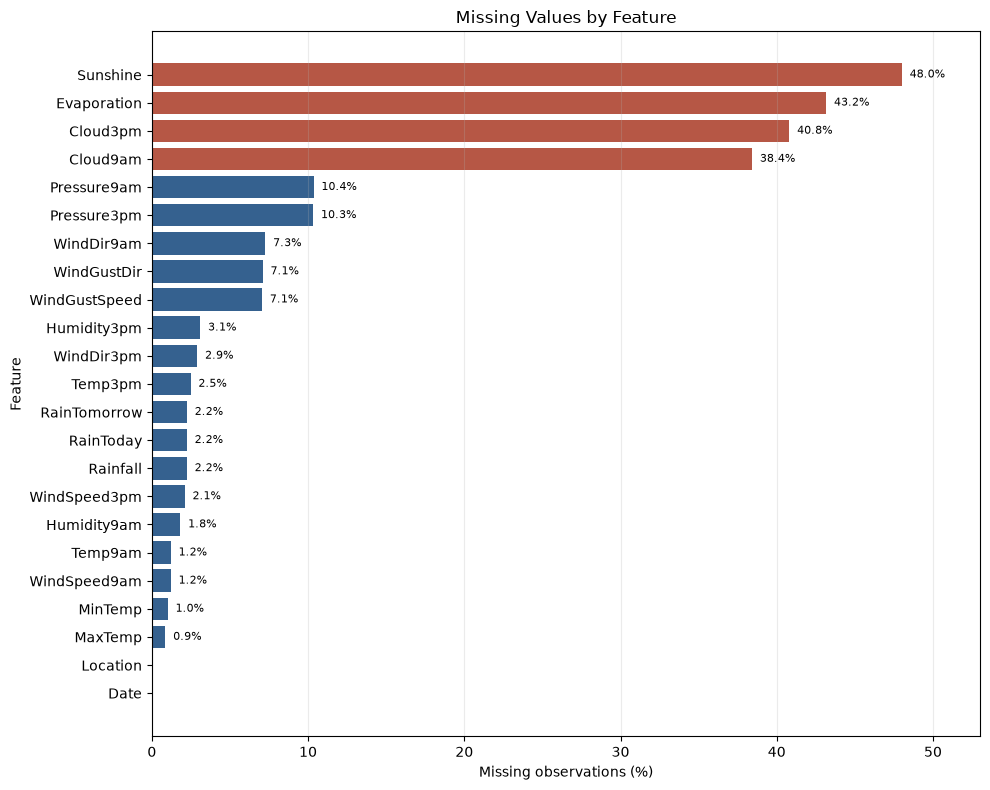

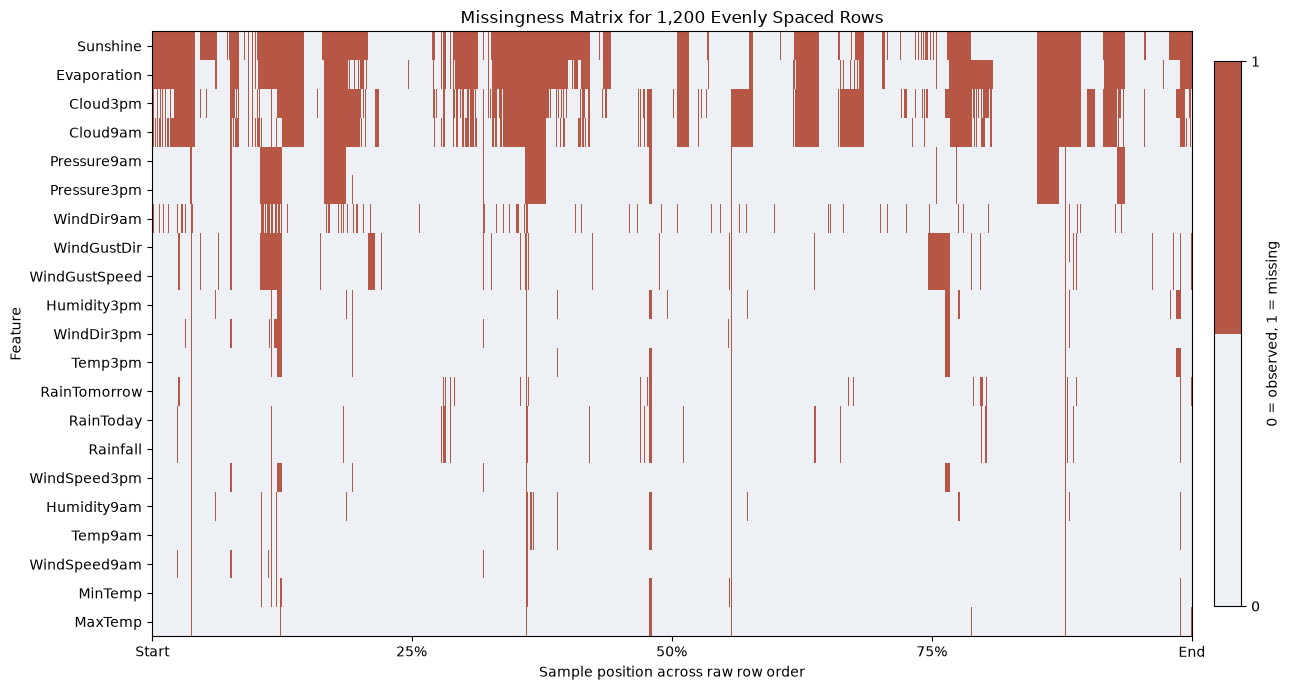

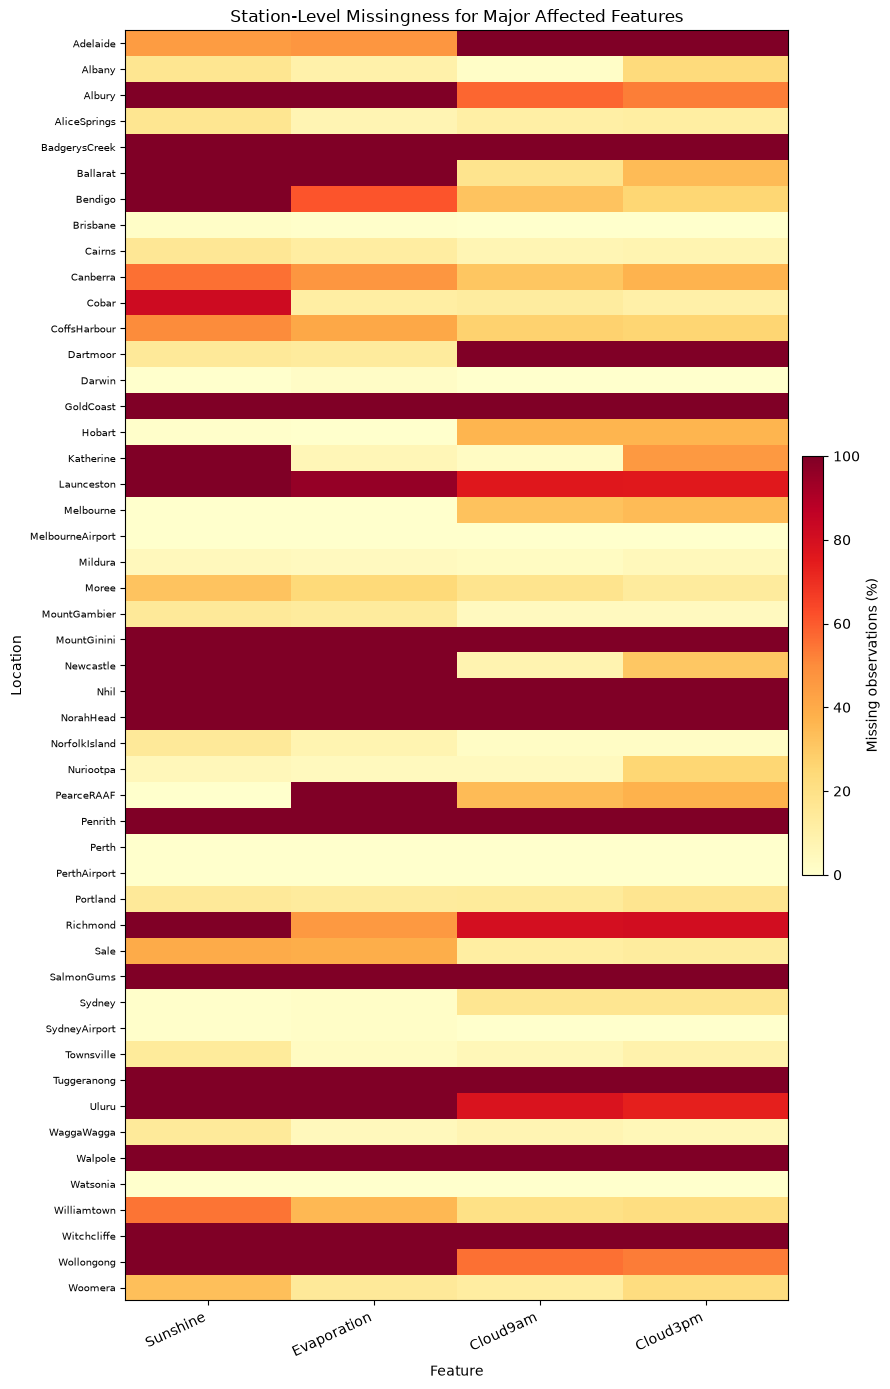

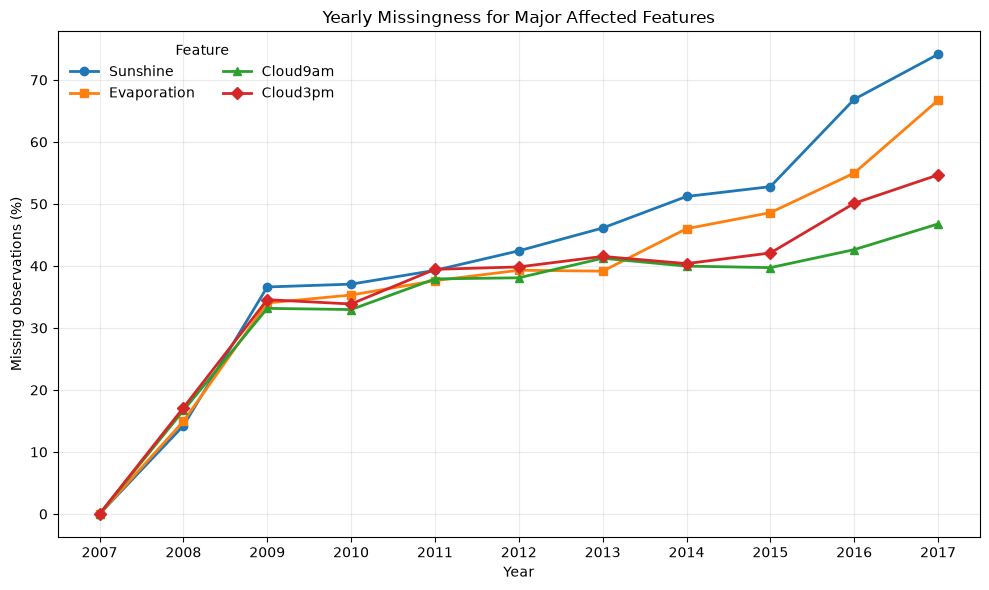

Saved 4 figures to reports\figures\missing_values


In [11]:
# 1. Missing percentage by feature
plot_data = missing_summary_table.sort_values('Missing percentage', ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#35618f' if value < 20 else '#b65745' for value in plot_data['Missing percentage']]
ax.barh(plot_data['Feature'], plot_data['Missing percentage'], color=colors)
ax.set_title('Missing Values by Feature')
ax.set_xlabel('Missing observations (%)')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.25)
for index, value in enumerate(plot_data['Missing percentage']):
    if value > 0:
        ax.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, max(52, plot_data['Missing percentage'].max() + 5))
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_missing_percentage_by_feature.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

# 2. Deterministic evenly spaced sample of row-level missingness
features_with_missing = missing_summary_table.query('`Missing count` > 0')['Feature'].tolist()
sample_indices = np.linspace(0, len(weather) - 1, 1200, dtype=int)
matrix = weather.iloc[sample_indices][features_with_missing].isna().to_numpy().T
fig, ax = plt.subplots(figsize=(13, 7))
image = ax.imshow(matrix, aspect='auto', interpolation='nearest', cmap=ListedColormap(['#edf1f5', '#b65745']))
ax.set_title('Missingness Matrix for 1,200 Evenly Spaced Rows')
ax.set_xlabel('Sample position across raw row order')
ax.set_ylabel('Feature')
ax.set_yticks(range(len(features_with_missing)), features_with_missing)
ax.set_xticks([0, 299, 599, 899, 1199], ['Start', '25%', '50%', '75%', 'End'])
fig.colorbar(image, ax=ax, ticks=[0, 1], label='0 = observed, 1 = missing', fraction=0.025, pad=0.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_missingness_matrix_sample.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

# 3. Station-level heatmap for major affected features
station_heatmap = (
    location_missing_table.query('Feature in @MAJOR_STRUCTURAL_FEATURES')
    .pivot(index='Location', columns='Feature', values='Missing percentage')
    .loc[:, list(MAJOR_STRUCTURAL_FEATURES)]
)
fig, ax = plt.subplots(figsize=(9, 14))
image = ax.imshow(station_heatmap.to_numpy(), aspect='auto', interpolation='nearest', cmap='YlOrRd', vmin=0, vmax=100)
ax.set_title('Station-Level Missingness for Major Affected Features')
ax.set_xlabel('Feature')
ax.set_ylabel('Location')
ax.set_xticks(range(len(station_heatmap.columns)), station_heatmap.columns, rotation=25, ha='right')
ax.set_yticks(range(len(station_heatmap.index)), station_heatmap.index, fontsize=7)
fig.colorbar(image, ax=ax, label='Missing observations (%)', fraction=0.03, pad=0.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_station_missingness_major_features.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

# 4. Yearly missingness trend for major affected features
fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^', 'D']
for marker, feature in zip(markers, MAJOR_STRUCTURAL_FEATURES):
    ax.plot(yearly_major.index, yearly_major[feature], marker=marker, linewidth=2, label=feature)
ax.set_title('Yearly Missingness for Major Affected Features')
ax.set_xlabel('Year')
ax.set_ylabel('Missing observations (%)')
ax.set_xticks(yearly_major.index)
ax.grid(alpha=0.25)
ax.legend(title='Feature', frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_temporal_missingness_major_features.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved 4 figures to {FIGURES_DIR.relative_to(PROJECT_ROOT)}')

## 11–13. Proposal verification and saved tables

Every supplied missing-count claim and each station-level absence claim is compared directly with the local dataset. Any mismatch remains visible.

In [12]:
proposal_missingness_table = proposal_missingness_comparison(weather, structural_missingness_table)
display(proposal_missingness_table)

tables = {
    '03_missing_summary.csv': missing_summary_table,
    '03_row_missing_overview.csv': row_missing_overview_table,
    '03_row_missing_distribution.csv': row_missing_distribution_table,
    '03_location_missing_summary.csv': location_missing_table,
    '03_complete_absence_locations.csv': complete_absence_locations_table,
    '03_structural_missingness.csv': structural_missingness_table,
    '03_temporal_missingness_summary.csv': temporal_missing_table,
    '03_location_year_missingness.csv': location_year_missing_table,
    '03_comissingness_summary.csv': comissingness_table,
    '03_target_missingness_summary.csv': target_missing_summary_table,
    '03_target_missingness_by_location.csv': target_missing_by_location_table,
    '03_target_missingness_by_year.csv': target_missing_by_year_table,
    '03_rainfall_raintoday_missingness.csv': rain_relationship_table,
    '03_proposal_missingness_comparison.csv': proposal_missingness_table,
    '03_interpretation_framework.csv': interpretation_framework_table,
}
for filename, table in tables.items():
    table.to_csv(TABLES_DIR / filename, index=False)
print(f'Saved {len(tables)} T03 tables to {TABLES_DIR.relative_to(PROJECT_ROOT)}')

,Claim,Expected value,Actual dataset value,Match / Mismatch,Comment
0,Sunshine missing count,69835,69835,Match,Direct count of missing values in the raw data...
1,Evaporation missing count,62790,62790,Match,Direct count of missing values in the raw data...
2,Cloud3pm missing count,59358,59358,Match,Direct count of missing values in the raw data...
3,Cloud9am missing count,55888,55888,Match,Direct count of missing values in the raw data...
4,Pressure9am missing count,15065,15065,Match,Direct count of missing values in the raw data...
5,Pressure3pm missing count,15028,15028,Match,Direct count of missing values in the raw data...
6,WindDir9am missing count,10566,10566,Match,Direct count of missing values in the raw data...
7,WindGustDir missing count,10326,10326,Match,Direct count of missing values in the raw data...
8,WindGustSpeed missing count,10263,10263,Match,Direct count of missing values in the raw data...
9,Sunshine is entirely absent at some stations,At least 1 station,19 stations,Match,A station is counted only when every row for t...


Saved 15 T03 tables to reports\tables


## T03 boundary

The analysis ends with evidence and future considerations. No data has been imputed, removed, encoded, scaled, transformed, or modelled. T04 has not started.